In [1]:
!pip install transformers datasets evaluate peft scikit-learn matplotlib torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.metrics import classification_report
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ==========================================
# 1. Tải Dataset và Tokenizer
# ==========================================
print("Loading dataset and tokenizer...")
dataset = load_dataset("glue", "qnli")
model_checkpoint = "t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess_function(examples):
    return tokenizer(
        examples['question'], 
        examples['sentence'], 
        truncation=True, 
        max_length=256
    )

print("Tokenizing data...")
encoded_dataset = dataset.map(preprocess_function, batched=True)

# ==========================================
# 2. Khởi tạo Model & Cấu hình LoRA
# ==========================================
print("Initializing Model and LoRA adapters...")
# Khởi tạo mô hình gốc
base_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

# Cấu hình LoRA
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, # Khai báo bài toán Sequence Classification
    r=8,                        # Rank của ma trận (càng lớn càng học được nhiều nhưng tốn RAM hơn)
    lora_alpha=32,              # Hệ số scale
    lora_dropout=0.1,           # Tránh overfitting
    target_modules=["q", "v"],  # Áp dụng LoRA vào các khối Query và Value của Attention layer
    modules_to_save=["classifier"] # Bắt buộc phải train full layer phân loại cuối cùng
)

# Bọc mô hình gốc bằng PEFT/LoRA
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters() # In ra số lượng tham số được train (thường chỉ chiếm < 1%)



Loading dataset and tokenizer...


README.md: 0.00B [00:00, ?B/s]

qnli/train-00000-of-00001.parquet:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

qnli/validation-00000-of-00001.parquet:   0%|          | 0.00/872k [00:00<?, ?B/s]

qnli/test-00000-of-00001.parquet:   0%|          | 0.00/877k [00:00<?, ?B/s]

...

Initializing Model and LoRA adapters...


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

T5ForSequenceClassification LOAD REPORT from: t5-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.out_proj.bias   | MISSING | 
classification_head.out_proj.weight | MISSING | 
classification_head.dense.weight    | MISSING | 
classification_head.dense.bias      | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 884,736 || all params: 224,380,418 || trainable%: 0.3943


In [3]:

# ==========================================
# 3. Cấu hình Metrics (KHÔNG in ra màn hình)
# ==========================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    predictions = np.argmax(logits, axis=-1)
    
    report = classification_report(labels, predictions, output_dict=True, zero_division=0)
    return {
        "f1_macro": report["macro avg"]["f1-score"], 
        "accuracy": report["accuracy"]
    }

# ==========================================
# 4. Cấu hình Training
# ==========================================
# Nhờ có LoRA, bạn ít bị Out-of-memory hơn, có thể đẩy batch_size lên 16 hoặc 32 tuỳ GPU
batch_size = 16 

args = TrainingArguments(
    output_dir="./t5-lora-qnli",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=1e-3,         # VỚI LORA, LEARNING RATE PHẢI CAO HƠN BÌNH THƯỜNG (thường dùng 1e-4 đến 5e-4)
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,                  # Bật tính toán 16-bit để train nhanh hơn nếu dùng GPU (Colab T4 có hỗ trợ)
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# ==========================================
# 5. Bắt đầu Train
# ==========================================
print("Bắt đầu huấn luyện với LoRA...")
trainer.train()


Bắt đầu huấn luyện với LoRA...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.753431,0.612329,0.873835,0.873879
2,0.644031,0.558471,0.884608,0.884862
3,0.601529,0.525326,0.892698,0.892733
4,0.558085,0.509541,0.901312,0.901336


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=13096, training_loss=0.6392692794287139, metrics={'train_runtime': 10947.6529, 'train_samples_per_second': 38.27, 'train_steps_per_second': 1.196, 'total_flos': 5.601585775406538e+16, 'train_loss': 0.6392692794287139, 'epoch': 4.0})

In [4]:
# ==========================================
# 6. Đánh giá Best Model
# ==========================================
print("\n" + "="*50)
print("ĐÁNH GIÁ BEST MODEL TRÊN TẬP VALIDATION")
print("="*50)

val_predictions = trainer.predict(encoded_dataset["validation"])

logits = val_predictions.predictions
if isinstance(logits, tuple):
    logits = logits[0]

best_preds = np.argmax(logits, axis=-1)
true_labels = val_predictions.label_ids

print(classification_report(
    true_labels, 
    best_preds, 
    target_names=["entailment", "not_entailment"], 
    digits=4
))



ĐÁNH GIÁ BEST MODEL TRÊN TẬP VALIDATION


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


                precision    recall  f1-score   support

    entailment     0.8799    0.9271    0.9029      2702
not_entailment     0.9247    0.8761    0.8998      2761

      accuracy                         0.9013      5463
     macro avg     0.9023    0.9016    0.9013      5463
  weighted avg     0.9025    0.9013    0.9013      5463



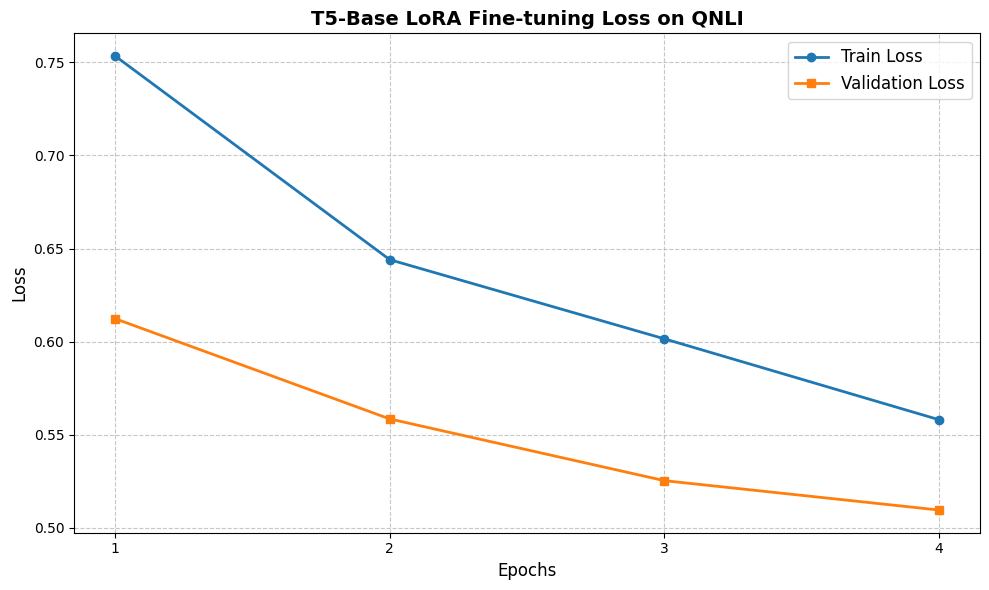

In [5]:
# ==========================================
# 7. Trích xuất Loss và Vẽ Đồ Thị
# ==========================================
log_history = trainer.state.log_history

epochs = []
train_loss = []
eval_loss = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        train_loss.append(log['loss'])
        if log['epoch'] not in epochs:
            epochs.append(log['epoch'])
    elif 'eval_loss' in log and 'epoch' in log:
        eval_loss.append(log['eval_loss'])

min_len = min(len(train_loss), len(eval_loss), len(epochs))
epochs = epochs[:min_len]
train_loss = train_loss[:min_len]
eval_loss = eval_loss[:min_len]

plt.figure(figsize=(10, 6), dpi=100)
plt.plot(epochs, train_loss, label='Train Loss', marker='o', linewidth=2)
plt.plot(epochs, eval_loss, label='Validation Loss', marker='s', linewidth=2)

plt.title('T5-Base LoRA Fine-tuning Loss on QNLI', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()